=== DESCRIBE: TOTAL ===
             homens      mulheres
count  3.300000e+01  3.300000e+01
mean   9.525940e+05  1.397796e+06
std    2.020681e+06  2.918446e+06
min    2.558500e+04  4.146000e+04
25%    1.311780e+05  2.015070e+05
50%    2.850130e+05  4.036650e+05
75%    6.954250e+05  9.925050e+05
max    1.047853e+07  1.537576e+07

=== DESCRIBE: STEM ===
             homens      mulheres
count  3.300000e+01  3.300000e+01
mean   2.500382e+05  1.271471e+05
std    5.490790e+05  2.707352e+05
min    4.958000e+03  3.057000e+03
25%    2.824100e+04  1.645900e+04
50%    6.393500e+04  3.210900e+04
75%    1.665790e+05  8.905600e+04
max    2.750422e+06  1.398619e+06

=== DESCRIBE: SAÚDE ===
             homens      mulheres
count  3.300000e+01  3.300000e+01
mean   1.525442e+05  5.819749e+05
std    3.144373e+05  1.197882e+06
min    5.880000e+03  1.809800e+04
25%    2.691100e+04  1.014430e+05
50%    5.656400e+04  1.902700e+05
75%    1.411690e+05  4.586160e+05
max    1.677985e+06  6.401723e+06


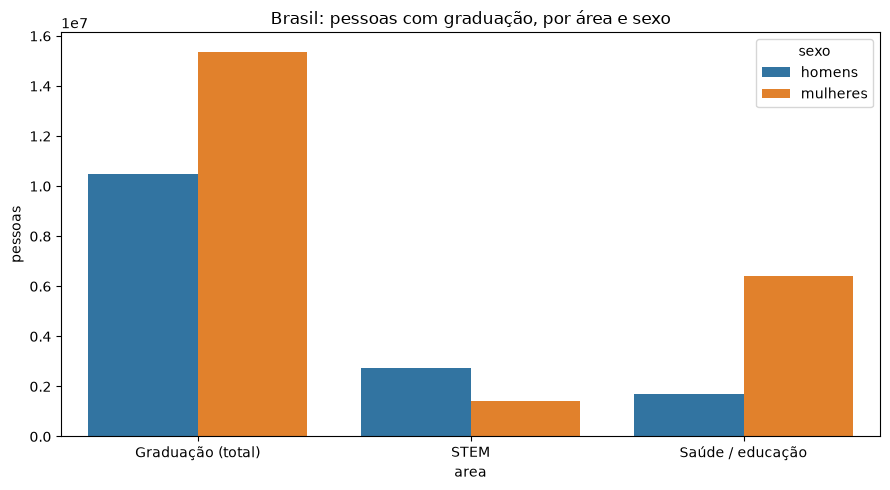

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

path_t3 = "Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx"
df3_raw = pd.read_excel(path_t3, header=None)

formacao_total = pd.DataFrame({
    'uf_regiao': df3_raw.iloc[3:36, 0],
    'homens': pd.to_numeric(df3_raw.iloc[3:36, 2], errors='coerce'),
    'mulheres': pd.to_numeric(df3_raw.iloc[3:36, 3], errors='coerce')
}).reset_index(drop=True)

formacao_stem = pd.DataFrame({
    'uf_regiao': df3_raw.iloc[3:36, 0],
    'homens': pd.to_numeric(df3_raw.iloc[3:36, 5], errors='coerce'),
    'mulheres': pd.to_numeric(df3_raw.iloc[3:36, 6], errors='coerce')
}).reset_index(drop=True)

formacao_saude = pd.DataFrame({
    'uf_regiao': df3_raw.iloc[3:36, 0],
    'homens': pd.to_numeric(df3_raw.iloc[3:36, 8], errors='coerce'),
    'mulheres': pd.to_numeric(df3_raw.iloc[3:36, 9], errors='coerce')
}).reset_index(drop=True)

formacao_total.to_excel("formacao_total.xlsx", index=False)
formacao_stem.to_excel("formacao_stem.xlsx", index=False)
formacao_saude.to_excel("formacao_saude.xlsx", index=False)

print("=== DESCRIBE: TOTAL ===")
print(formacao_total.describe())
print("\n=== DESCRIBE: STEM ===")
print(formacao_stem.describe())
print("\n=== DESCRIBE: SAÚDE ===")
print(formacao_saude.describe())

brasil_tot = formacao_total.loc[formacao_total["uf_regiao"] == "Brasil"]
brasil_st = formacao_stem.loc[formacao_stem["uf_regiao"] == "Brasil"]
brasil_sd = formacao_saude.loc[formacao_saude["uf_regiao"] == "Brasil"]

brasil = pd.DataFrame({
    "area": ["Graduação (total)", "STEM", "Saúde / educação"],
    "homens": [brasil_tot["homens"].item(), brasil_st["homens"].item(), brasil_sd["homens"].item()],
    "mulheres": [brasil_tot["mulheres"].item(), brasil_st["mulheres"].item(), brasil_sd["mulheres"].item()],
})
brasil_long = brasil.melt(id_vars="area", var_name="sexo", value_name="pessoas")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=brasil_long, x="area", y="pessoas", hue="sexo", ax=ax)
ax.set_title("Brasil: pessoas com graduação, por área e sexo")
plt.tight_layout()
plt.show()

In [2]:
!pip install pandas matplotlib seaborn xlrd openpyxl


Defaulting to user installation because normal site-packages is not writeable
